# Neuronale Netze in PyTorch: Konfiguration, Tuning & Regularisierung

Ein praktischer Leitfaden mit Beispielen.

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Device konfigurieren (M3 Mac: MPS)
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'PyTorch Version: {torch.__version__}')
print(f'Device: {device}')

PyTorch Version: 2.9.1
Device: mps


In [36]:
# MNIST laden
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Training: {len(train_dataset)}, Test: {len(test_dataset)}')

Training: 60000, Test: 10000


---
## 1. Architektur-Parameter

Die grundlegenden Stellschrauben deines Netzwerks.

### 1.1 Anzahl und Größe der Layer

In [37]:
# Klein: Schnell, aber begrenzte Kapazität
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Mittel: Gute Balance
class MediumNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Groß: Mehr Kapazität, aber Overfitting-Gefahr
class LargeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

# Parameter zählen
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f'Klein:  {count_params(SmallNet()):,} Parameter')
print(f'Mittel: {count_params(MediumNet()):,} Parameter')
print(f'Groß:   {count_params(LargeNet()):,} Parameter')

Klein:  50,890 Parameter
Mittel: 109,386 Parameter
Groß:   567,434 Parameter


### 1.2 Flexible Architektur mit nn.Sequential

In [38]:
# Kompakte Schreibweise
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)


### 1.3 Aktivierungsfunktionen

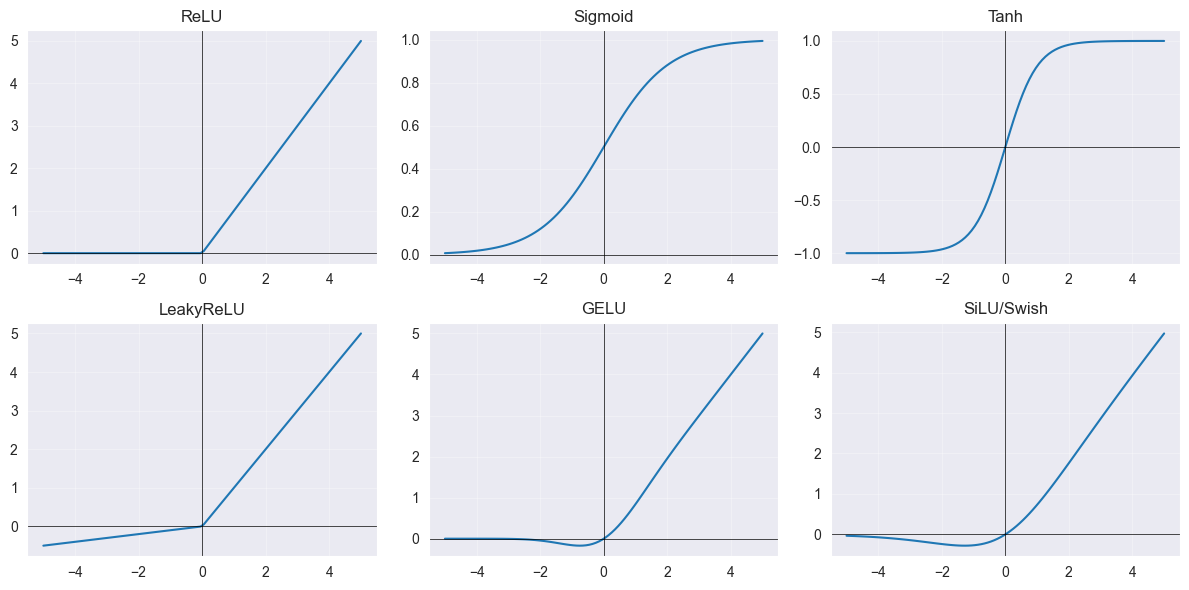

In [39]:
# Visualisierung der Aktivierungsfunktionen
x = torch.linspace(-5, 5, 100)

activations = {
    'ReLU': torch.relu(x),
    'Sigmoid': torch.sigmoid(x),
    'Tanh': torch.tanh(x),
    'LeakyReLU': nn.functional.leaky_relu(x, 0.1),
    'GELU': nn.functional.gelu(x),
    'SiLU/Swish': nn.functional.silu(x)
}

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (name, y) in zip(axes.flat, activations.items()):
    ax.plot(x.numpy(), y.numpy())
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

In [40]:
# Verwendung als Module
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),              # Standard
    nn.Linear(128, 64),
    nn.LeakyReLU(0.1),      # Mit negativer Steigung
    nn.Linear(64, 32),
    nn.GELU(),              # Smooth, gut für Transformer
    nn.Linear(32, 10)
)

**Empfehlungen:**

| Aktivierung | Wann verwenden |
|-------------|----------------|
| `nn.ReLU()` | Standard für Hidden Layers |
| `nn.LeakyReLU(0.1)` | Wenn ReLU "tote" Neuronen produziert |
| `nn.GELU()` | Transformer, moderne Architekturen |
| `nn.Sigmoid()` | Binäre Klassifikation (Output) |
| `nn.Softmax(dim=1)` | Multi-Klassen (meist in Loss integriert) |
| Keine | Regression (Output) |

---
## 2. Regularisierung

Techniken gegen Overfitting.

### 2.1 Dropout

In [41]:
class DropoutNet(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # 30% ausschalten
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

# Wichtig: model.train() aktiviert Dropout
#          model.eval() deaktiviert Dropout
model = DropoutNet(0.3)
print(model)

DropoutNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 2.2 L2 Regularisierung (Weight Decay)

In [42]:
# In PyTorch: weight_decay im Optimizer
model = MediumNet()

# L2 Regularisierung mit weight_decay
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

# Alternativ: AdamW (bessere Weight Decay Implementierung)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Typische Werte: 0.0001 - 0.01

### 2.3 Batch Normalization

In [43]:
class BatchNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),  # Nach Linear, vor Aktivierung
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

# Wichtig: BatchNorm verhält sich anders in train() vs eval()
model = BatchNormNet()
print(model)

BatchNormNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 2.4 Layer Normalization (Alternative)

In [44]:
# LayerNorm: Unabhängig von Batch Size, gut für kleine Batches
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.LayerNorm(128),  # Normalisiert über Features statt Batch
    nn.ReLU(),
    nn.Linear(128, 10)
)

### 2.5 Gradient Clipping

In [45]:
# Verhindert explodierende Gradienten
model = MediumNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Im Training Loop:
def train_step_with_clipping(model, data, target, optimizer, max_norm=1.0):
    optimizer.zero_grad()
    output = model(data)
    loss = nn.functional.cross_entropy(output, target)
    loss.backward()
    
    # Gradient Clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
    
    optimizer.step()
    return loss.item()

---
## 3. Optimizer & Learning Rate

Wie das Netzwerk lernt.

### 3.1 Optimizer-Vergleich

In [46]:
model = MediumNet()

# SGD: Einfach, braucht mehr Tuning
opt_sgd = optim.SGD(model.parameters(), lr=0.01)

# SGD mit Momentum: Schnellere Konvergenz
opt_sgd_momentum = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# SGD mit Nesterov Momentum: Noch besser
opt_sgd_nesterov = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)

# Adam: Adaptiv, meist beste Wahl
opt_adam = optim.Adam(model.parameters(), lr=0.001)

# AdamW: Adam mit korrektem Weight Decay
opt_adamw = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# RMSprop: Gut für RNNs
opt_rmsprop = optim.RMSprop(model.parameters(), lr=0.001)

**Empfehlung:** Starte mit `AdamW(lr=0.001, weight_decay=0.01)`

### 3.2 Learning Rate Scheduler

In [47]:
model = MediumNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# StepLR: Reduziert LR alle N Epochen
scheduler_step = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# ExponentialLR: Exponentieller Decay
scheduler_exp = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# ReduceLROnPlateau: Reduziert wenn Metrik stagniert (sehr empfohlen)
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',          # Minimiere val_loss
    factor=0.5,          # LR halbieren
    patience=3          # Nach 3 Epochen ohne Verbesserung
)

# CosineAnnealingLR: Cosinus-Verlauf
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# OneCycleLR: Warmup + Decay (sehr effektiv)
scheduler_onecycle = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    epochs=10,
    steps_per_epoch=len(train_loader)
)

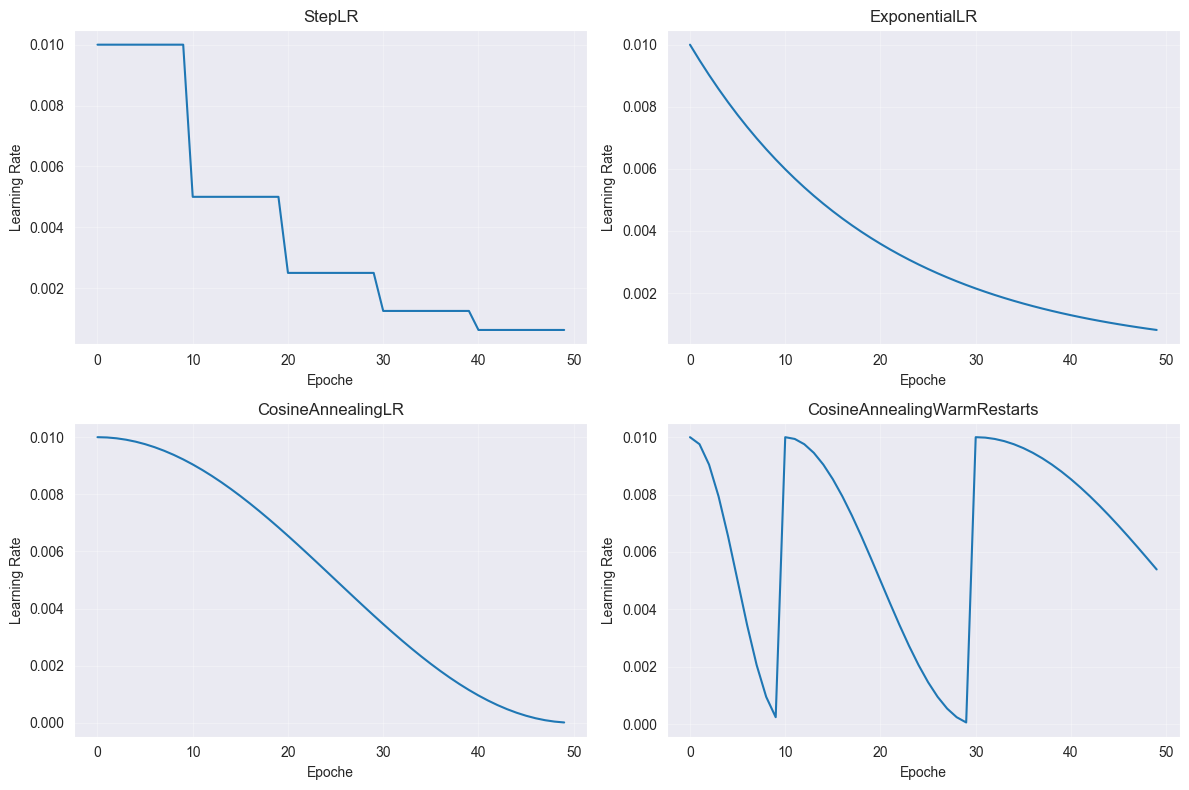

In [48]:
# Visualisierung der Scheduler
def visualize_scheduler(scheduler_class, optimizer_params, scheduler_params, epochs=50):
    model = nn.Linear(10, 10)
    optimizer = optim.Adam(model.parameters(), **optimizer_params)
    scheduler = scheduler_class(optimizer, **scheduler_params)
    
    lrs = []
    for _ in range(epochs):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    
    return lrs

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# StepLR
lrs = visualize_scheduler(optim.lr_scheduler.StepLR, {'lr': 0.01}, {'step_size': 10, 'gamma': 0.5})
axes[0, 0].plot(lrs)
axes[0, 0].set_title('StepLR')

# ExponentialLR
lrs = visualize_scheduler(optim.lr_scheduler.ExponentialLR, {'lr': 0.01}, {'gamma': 0.95})
axes[0, 1].plot(lrs)
axes[0, 1].set_title('ExponentialLR')

# CosineAnnealingLR
lrs = visualize_scheduler(optim.lr_scheduler.CosineAnnealingLR, {'lr': 0.01}, {'T_max': 50})
axes[1, 0].plot(lrs)
axes[1, 0].set_title('CosineAnnealingLR')

# CosineAnnealingWarmRestarts
lrs = visualize_scheduler(optim.lr_scheduler.CosineAnnealingWarmRestarts, {'lr': 0.01}, {'T_0': 10, 'T_mult': 2})
axes[1, 1].plot(lrs)
axes[1, 1].set_title('CosineAnnealingWarmRestarts')

for ax in axes.flat:
    ax.set_xlabel('Epoche')
    ax.set_ylabel('Learning Rate')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Training Loop mit allen Techniken

In [49]:
class TunedNet(nn.Module):
    """Gut konfiguriertes Modell mit Regularisierung."""
    
    def __init__(self, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

In [50]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = nn.functional.cross_entropy(output, target)
        loss.backward()
        
        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
    
    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = nn.functional.cross_entropy(output, target)
            
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    
    return total_loss / len(loader), correct / total

In [51]:
class EarlyStopping:
    """Stoppt Training wenn Validierung nicht mehr besser wird."""
    
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_weights = None
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_weights = model.state_dict().copy()
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_weights = model.state_dict().copy()
            self.counter = 0
    
    def restore_best_weights(self, model):
        model.load_state_dict(self.best_weights)

In [52]:
# Training
model = TunedNet(dropout=0.3).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
early_stopping = EarlyStopping(patience=5)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

EPOCHS = 10
print('Training gestartet...\n')

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, device)
    
    # Scheduler step
    scheduler.step(val_loss)
    
    # History speichern
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Early Stopping prüfen
    early_stopping(val_loss, model)
    
    print(f'Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    
    if early_stopping.early_stop:
        print(f'\nEarly Stopping nach Epoch {epoch+1}')
        early_stopping.restore_best_weights(model)
        break

print('\nTraining abgeschlossen!')

Training gestartet...

Epoch  1 | Train Loss: 0.2881 Acc: 0.9183 | Val Loss: 0.1094 Acc: 0.9636
Epoch  2 | Train Loss: 0.1502 Acc: 0.9542 | Val Loss: 0.0814 Acc: 0.9742
Epoch  3 | Train Loss: 0.1176 Acc: 0.9628 | Val Loss: 0.0674 Acc: 0.9789
Epoch  4 | Train Loss: 0.1011 Acc: 0.9670 | Val Loss: 0.0644 Acc: 0.9806
Epoch  5 | Train Loss: 0.0901 Acc: 0.9714 | Val Loss: 0.0656 Acc: 0.9790
Epoch  6 | Train Loss: 0.0847 Acc: 0.9728 | Val Loss: 0.0563 Acc: 0.9826
Epoch  7 | Train Loss: 0.0757 Acc: 0.9757 | Val Loss: 0.0547 Acc: 0.9833
Epoch  8 | Train Loss: 0.0710 Acc: 0.9769 | Val Loss: 0.0600 Acc: 0.9810
Epoch  9 | Train Loss: 0.0658 Acc: 0.9790 | Val Loss: 0.0580 Acc: 0.9821
Epoch 10 | Train Loss: 0.0615 Acc: 0.9805 | Val Loss: 0.0543 Acc: 0.9825

Training abgeschlossen!


Test Accuracy: 98.25%


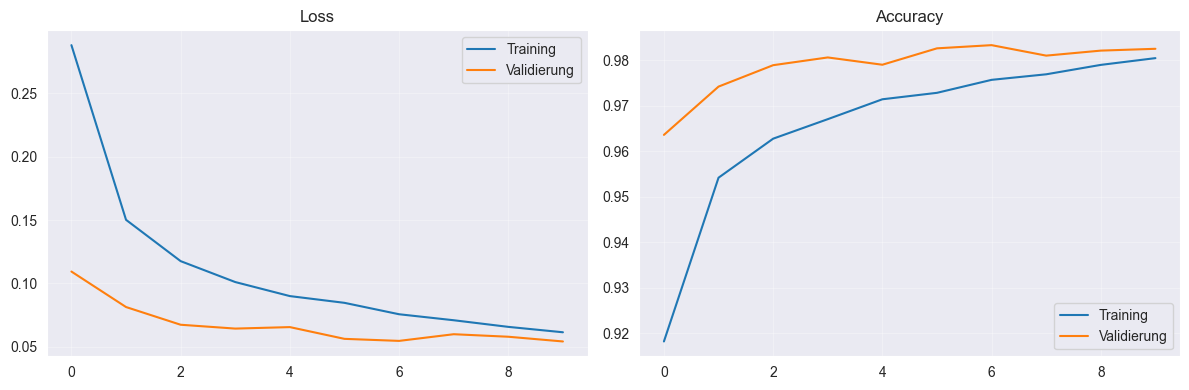

In [53]:
# Ergebnis
test_loss, test_acc = evaluate(model, test_loader, device)
print(f'Test Accuracy: {test_acc*100:.2f}%')

# Trainingsverlauf
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Training')
axes[0].plot(history['val_loss'], label='Validierung')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Training')
axes[1].plot(history['val_acc'], label='Validierung')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Modell speichern & laden

In [54]:
# Nur Gewichte speichern (empfohlen)
torch.save(model.state_dict(), 'model_weights.pth')

# Laden
loaded_model = TunedNet().to(device)
loaded_model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
loaded_model.eval()

print('Modell geladen!')

Modell geladen!


In [55]:
# Kompletter Checkpoint (mit Optimizer, Epoch, etc.)
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}
torch.save(checkpoint, 'checkpoint.pth')

# Laden
checkpoint = torch.load('checkpoint.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

print(f'Checkpoint geladen (Epoch {checkpoint["epoch"]})')

Checkpoint geladen (Epoch 9)


---
## 6. Zusammenfassung: Tuning-Checkliste

| Problem | Lösung |
|---------|--------|
| **Overfitting** (Val-Loss steigt) | Dropout ↑, weight_decay ↑, Early Stopping, weniger Layer |
| **Underfitting** (beide Losses hoch) | Mehr Layer/Neuronen, weniger Regularisierung |
| **Training instabil** | Learning Rate ↓, BatchNorm, Gradient Clipping |
| **Training zu langsam** | Learning Rate ↑, Batch Size ↑ |
| **Loss explodiert** | Learning Rate ↓, Gradient Clipping |

### Typische Startwerte

```python
# Architektur
hidden_units = 128         # Pro Layer
num_layers = 2-3           # Hidden Layers
activation = nn.ReLU()     # Hidden Layers

# Regularisierung  
dropout = 0.2-0.3          # Nach Dense Layers
weight_decay = 0.01        # Im Optimizer (AdamW)

# Training
optimizer = AdamW(lr=0.001, weight_decay=0.01)
scheduler = ReduceLROnPlateau(factor=0.5, patience=3)
batch_size = 32-64
epochs = 50                # Mit Early Stopping
```

### PyTorch vs TensorFlow

| Feature | PyTorch | TensorFlow |
|---------|---------|------------|
| Dropout | `nn.Dropout(p)` | `layers.Dropout(rate)` |
| L2 Reg | `weight_decay` im Optimizer | `kernel_regularizer=l2()` |
| BatchNorm | `nn.BatchNorm1d(features)` | `layers.BatchNormalization()` |
| Train/Eval | `model.train()` / `model.eval()` | Automatisch |
| Gradient Clip | `clip_grad_norm_()` | `clipnorm` im Optimizer |